# Cardiovascular Risk Profiling — Exploratory Data Analysis

**Dataset:** Indian Heart Health Survey (10,000 respondents)

This notebook cleans the raw survey data, engineers the risk features used
downstream in SQL and Power BI, and explores the key patterns in the data
visually before handing off to the MySQL KPI layer.

**Contents**
1. Load & Inspect
2. Missing Value Imputation
3. Feature Engineering
4. Text Normalization & Outlier Audit
5. Exploratory Visual Analysis
6. Export Cleaned Dataset


## 1. Load & Inspect

In [1]:
import pandas as pd
import numpy as np

#loading dataset
df = pd.read_csv('../data/raw/indian_heart_health_survey_10k.csv')

# a)Standardizing Column Names
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# b)Checking and remove=ing duplicates
initial_count = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {initial_count - len(df)} duplicate rows.")

#c) Quick Inspection
print(df.info())

Removed 0 duplicate rows.
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   age                           10000 non-null  int64
 1   gender                        10000 non-null  str  
 2   location_tier                 10000 non-null  str  
 3   city_name                     10000 non-null  str  
 4   living_area_type              10000 non-null  str  
 5   air_quality_level             10000 non-null  str  
 6   aqi_device_available          10000 non-null  str  
 7   education_level               8010 non-null   str  
 8   occupation_type               10000 non-null  str  
 9   family_size                   10000 non-null  int64
 10  family_income_per_year        10000 non-null  str  
 11  smoker_in_house               10000 non-null  str  
 12  fuel_type_used                10000 non-null  str  
 13  water_source     

## 2. Missing Value Imputation

Filling missing `education_level` using the most frequent value **within each occupation type**, rather than a blanket "Unknown".

In [2]:
# 1)Fill missing education_level based on the most frequent (mode) education for that occupation
# much more accurate than filling with a static 'Unknown'
df['education_level'] = df.groupby('occupation_type')['education_level'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Not Disclosed")
)

# 2) Verifing Check if nulls are now 0
print(f"Missing values after imputation: {df['education_level'].isnull().sum()}")

Missing values after imputation: 0


## 3. Feature Engineering

Creating `income_rank` (ordinal income scale), `high_risk_flag` (composite clinical risk indicator), and `age_group` (generational bins).

In [3]:
# 1)income Ranking (Ordinal Encoding)
# Converting text like '< 3L' into numbers (1, 2, 3, 4) for mathematical analysis
income_map = {'< 3L': 1, '3–6L': 2, '6–10L': 3, '10L+': 4}
df['income_rank'] = df['family_income_per_year'].map(income_map)

# 2. Creating the 'High_Risk_Flag' (Composite Feature)
# We define 'High Risk' (1) if a person
# has at least 2 out of 4 clinical "Red Flags".
def define_risk(row):
    red_flags = 0
    if row['known_hypertension'] == 'Yes': red_flags += 1
    if row['known_diabetes'] == 'Yes': red_flags += 1
    if row['heart_symptoms_past_year'] == 'Yes': red_flags += 1
    if row['family_history_heart_disease'] == 'Yes': red_flags += 1
    return 1 if red_flags >= 2 else 0

df['high_risk_flag'] = df.apply(define_risk, axis=1)

# 3) Age Binning (Categorical )
# Helps the Power BI team create better visuals for different generations
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 50, 75, 120], labels=['Young', 'Adult', 'Mid-Senior', 'Senior'])

print("Feature Engineering Complete. Created: income_rank, high_risk_flag, age_group")

Feature Engineering Complete. Created: income_rank, high_risk_flag, age_group


## 4. Text Normalization & Outlier Audit

Standardizing text casing for clean SQL joins, then auditing for impossible age/family-size values.

In [4]:
# 1)Text Normalization: Enforce Title Case & Strip Spaces
# This ensures "mumbai" and " Mumbai " both become "Mumbai" for SQL Joins
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.title()

# 2)Outlier Detection (The Audit)
# We check if Age is within human limits (0-110) and Family Size is > 0
age_outliers = df[(df['age'] < 0) | (df['age'] > 110)]
family_outliers = df[df['family_size'] < 1]

print(f"Audit Findings - Age Outliers: {len(age_outliers)}")
print(f"Audit Findings - Family Size Outliers: {len(family_outliers)}")

# If outliers found, this line removes them to ensure statistical integrity
df = df[(df['age'] >= 0) & (df['age'] <= 110)]
df = df[df['family_size'] >= 1]

print("Data Consistency & Audit Complete + all text normalized and outliers verified.")

Audit Findings - Age Outliers: 0
Audit Findings - Family Size Outliers: 0
Data Consistency & Audit Complete + all text normalized and outliers verified.


/tmp/ipykernel_545/2922693660.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


## 5. Exploratory Visual Analysis

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110

### 5.1 Respondent Age Distribution

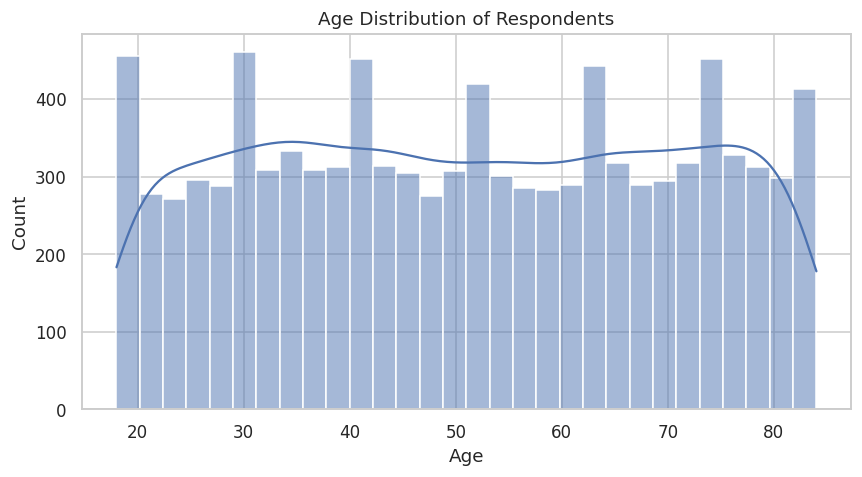

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df['age'], bins=30, kde=True, color='#4C72B0', ax=ax)
ax.set_title('Age Distribution of Respondents')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 5.2 Overall High-Risk Share

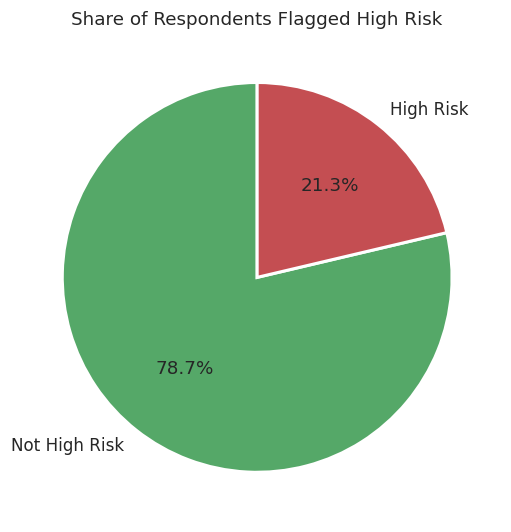

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
risk_counts = df['high_risk_flag'].map({0: 'Not High Risk', 1: 'High Risk'}).value_counts()
colors = ['#55A868', '#C44E52']
ax.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', colors=colors,
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Share of Respondents Flagged High Risk')
plt.tight_layout()
plt.show()

### 5.3 High-Risk Rate by City (Top 10)

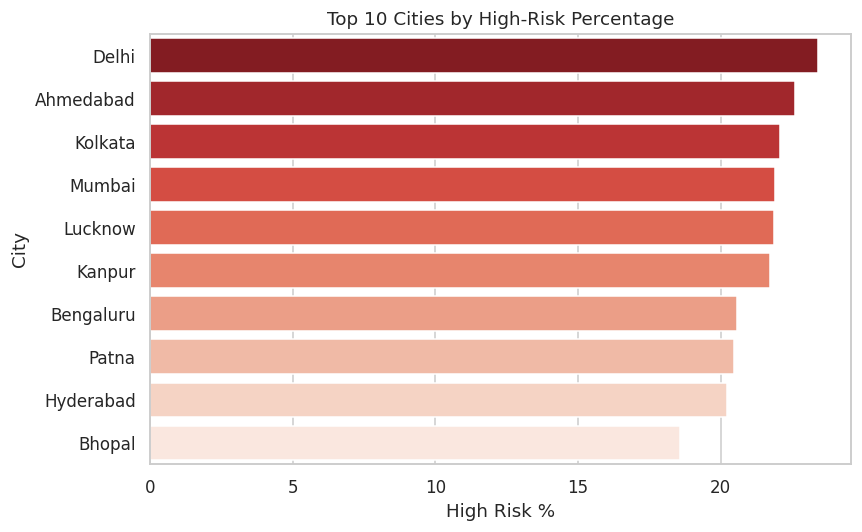

In [8]:
city_risk = (df.groupby('city_name')['high_risk_flag'].mean() * 100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=city_risk.values, y=city_risk.index, hue=city_risk.index, palette='Reds_r', legend=False, ax=ax)
ax.set_title('Top 10 Cities by High-Risk Percentage')
ax.set_xlabel('High Risk %')
ax.set_ylabel('City')
plt.tight_layout()
plt.show()

### 5.4 High-Risk Rate by Income Rank

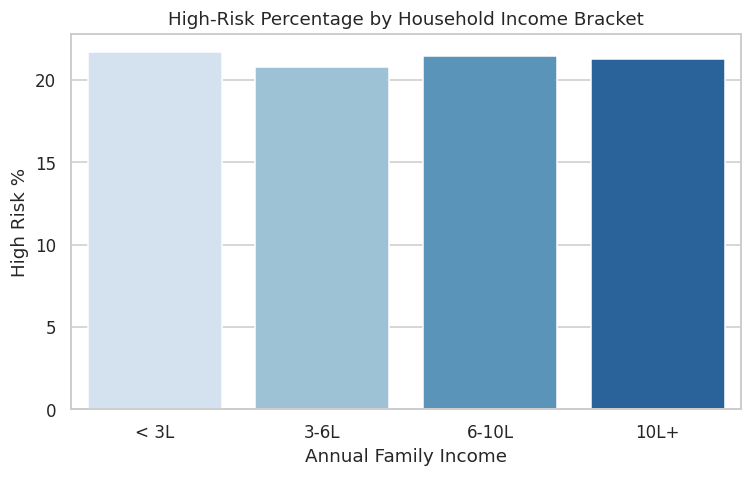

In [9]:
income_risk = df.groupby('income_rank')['high_risk_flag'].mean() * 100
income_labels = {1: '< 3L', 2: '3-6L', 3: '6-10L', 4: '10L+'}

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=[income_labels[i] for i in income_risk.index], y=income_risk.values,
            hue=[income_labels[i] for i in income_risk.index], palette='Blues', legend=False, ax=ax)
ax.set_title('High-Risk Percentage by Household Income Bracket')
ax.set_xlabel('Annual Family Income')
ax.set_ylabel('High Risk %')
plt.tight_layout()
plt.show()

### 5.5 Age Inflection Point (5-Year Rolling Risk Trend)

Where does cardiovascular risk start climbing meaningfully? This rolling
average is the same logic later implemented as a SQL window function for
the "Critical Screening Age" KPI.

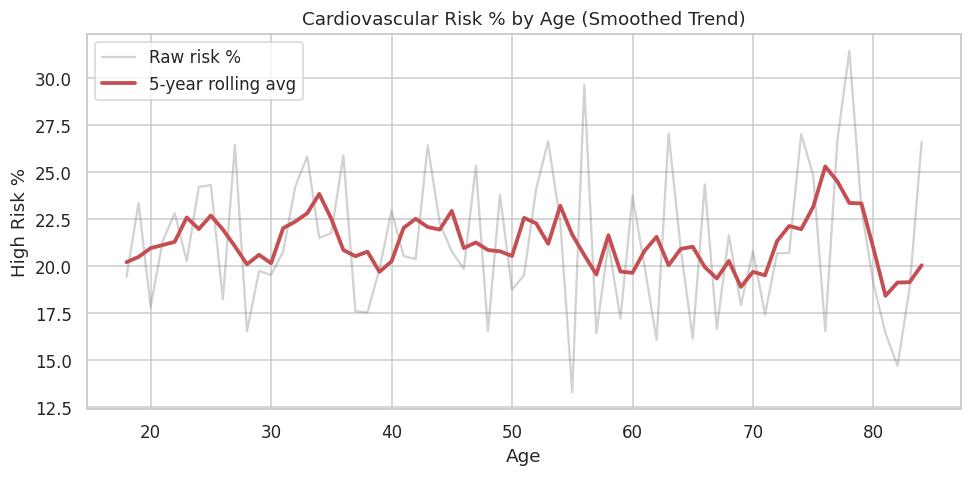

In [10]:
age_risk = (df.groupby('age')['high_risk_flag'].mean() * 100).rename('raw_risk_pct').reset_index()
age_risk['smoothed'] = age_risk['raw_risk_pct'].rolling(window=5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(age_risk['age'], age_risk['raw_risk_pct'], alpha=0.35, color='gray', label='Raw risk %')
ax.plot(age_risk['age'], age_risk['smoothed'], linewidth=2.5, color='#C44E52', label='5-year rolling avg')
ax.set_title('Cardiovascular Risk % by Age (Smoothed Trend)')
ax.set_xlabel('Age')
ax.set_ylabel('High Risk %')
ax.legend()
plt.tight_layout()
plt.show()

### 5.6 Air Quality × Exercise Level Risk Matrix

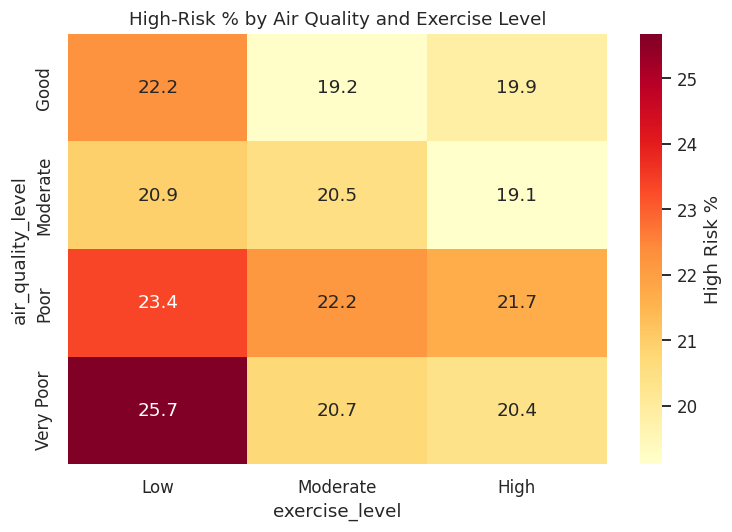

In [11]:
matrix = df.pivot_table(index='air_quality_level', columns='exercise_level',
                         values='high_risk_flag', aggfunc='mean') * 100
order_aqi = ['Good', 'Moderate', 'Poor', 'Very Poor']
order_ex = ['Low', 'Moderate', 'High']
matrix = matrix.reindex(index=[i for i in order_aqi if i in matrix.index],
                         columns=[c for c in order_ex if c in matrix.columns])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(matrix, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'High Risk %'}, ax=ax)
ax.set_title('High-Risk % by Air Quality and Exercise Level')
plt.tight_layout()
plt.show()

### 5.7 Diet Type vs High-Risk Rate

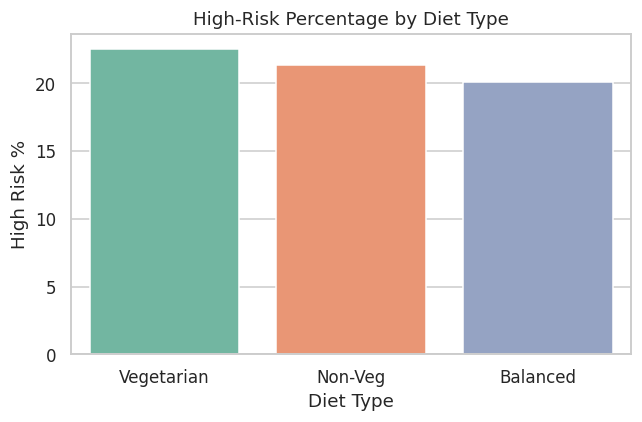

In [12]:
diet_risk = (df.groupby('diet_type')['high_risk_flag'].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=diet_risk.index, y=diet_risk.values, hue=diet_risk.index, palette='Set2', legend=False, ax=ax)
ax.set_title('High-Risk Percentage by Diet Type')
ax.set_xlabel('Diet Type')
ax.set_ylabel('High Risk %')
plt.tight_layout()
plt.show()

### 5.8 Correlation Snapshot (Numeric Features)

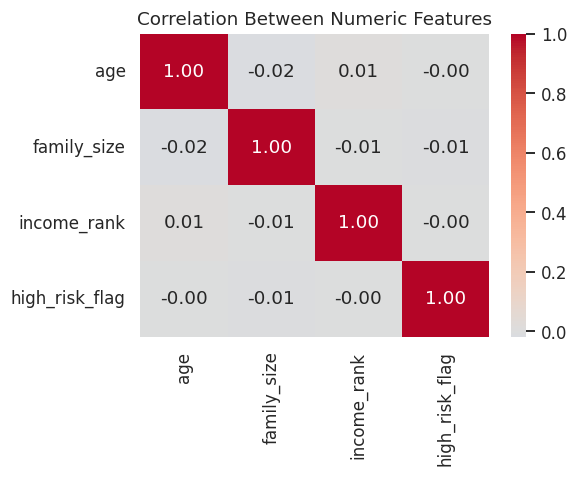

In [13]:
numeric_cols = ['age', 'family_size', 'income_rank', 'high_risk_flag']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()

## 6. Export Cleaned Dataset

In [14]:
# 1)Droping administrative/unnecessary columns that aren't needed for analysis
# This makes the file lighter and easier for my SQL import
cols_to_drop = ['consent_for_use', 'data_sharing_consent']
final_df = df.drop(columns=cols_to_drop)

# 2)Exportingg the final dataset
final_df.to_csv('../data/processed/heart_health_FINAL_CLEANED.csv', index=False)


# Colab-only download helper — skipped automatically when not running in Colab
try:
    from google.colab import files
    files.download('heart_health_FINAL_CLEANED.csv')
except ImportError:
    pass

print("Date cleaning done ")

Date cleaning done 


---
**Next step:** this cleaned CSV feeds `sql/schema.sql`, where 10 KPI views
(`sql/queries/`) answer the deeper regional, socio-economic, and behavioral
risk questions explored above — see the main `README.md` for the full
pipeline and findings summary.